# House price prediction using Linear Regression
Name-Khushi Tomar  
University Rollno- 202401100500086

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alyelbadry/house-pricing-dataset")
print("Dataset path:", path)

c:\Users\Khushi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\Khushi\.cache\kagglehub\datasets\alyelbadry\house-pricing-dataset\versions\1


In [2]:
import os
csv_path = os.path.join(path, "house_prices.csv")

In [3]:
import pandas as pd
df=pd.read_csv(csv_path)
print(df.columns)
print(df.info)
print(df.shape)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')
<bound method DataFrame.info of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0       

In [4]:
df=df.drop(["date","id","zipcode"],axis=1)

In [5]:
df=pd.get_dummies(df)

In [6]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [7]:
y=df["price"]
x=df[["sqft_living","sqft_living","bedrooms","bathrooms","floors","view","grade","sqft_above","sqft_lot","sqft_basement"]]

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
X_test_orig=x_test.copy()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred=model.predict(x_test) #y_test

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
print("Mean squared Error : ", mean_squared_error(y_test,y_pred))
print("R2 Score : ", r2_score(y_test,y_pred))

Mean squared Error :  22082570364.23076
R2 Score :  0.4697304805676361


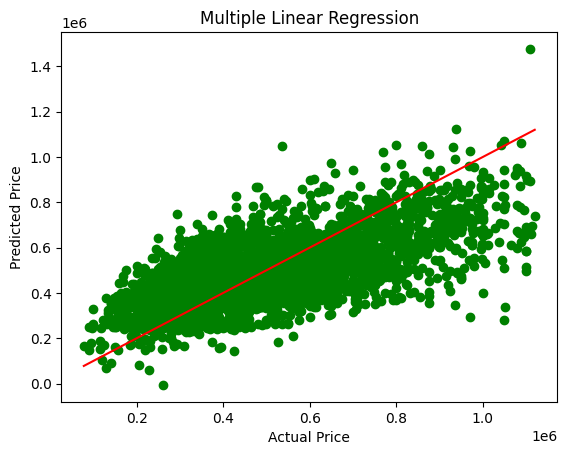

In [13]:
import matplotlib.pyplot as plt
import numpy as np

y_actual = np.array(y_test).ravel()
y_predicted = np.array(y_pred).ravel()

plt.scatter(y_actual, y_predicted, color='green')

# perfect prediction line
plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression")

plt.show()


In [16]:
from sklearn.metrics import mean_absolute_error
new_house = pd.DataFrame({'sqft_living': [2000]})

new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print("Predicted price for 2000 sq.ft:", predicted_price[0])

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- bathrooms
- bedrooms
- floors
- grade
- sqft_above
- ...
